In [ ]:
!pip install -q imbalanced-learn openpyxl

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

# ============================================================
# STILE FIGURE PER ARTICOLO SCIENTIFICO
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 14,
    "axes.linewidth": 0.8
})

# ============================================================
# CARTELLA PER SALVATAGGIO FIGURE IN PDF
# ============================================================

FIG_DIR = Path("figures_pdf")
FIG_DIR.mkdir(exist_ok=True)

def save_pdf(fig, filename):
    fig.savefig(
        FIG_DIR / f"{filename}.pdf",
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.02
    )

# ============================================================
# IMPORT SCIKIT-LEARN
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [ ]:
# Dataset path for the repository version.
# The first path works when the notebook is run from the `notebooks/` folder;
# the second path works when it is run from the repository root.
candidate_paths = [
    Path("../dataset/dataset_additives.xlsx"),
    Path("dataset/dataset_additives.xlsx"),
    Path("dataset_additives.xlsx"),
]

dataset_path = next((path for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Dataset not found. Expected `dataset/dataset_additives.xlsx` in the repository."
    )

print(f"Using dataset: {dataset_path}")


In [ ]:
df = pd.read_excel(
    dataset_path,
    keep_default_na=False
)

df.columns = [
    "material",
    "percentage",
    "Tg",
    "young_modulus",
    "stress",
    "strain"
]

for col in ["percentage", "Tg", "young_modulus", "stress", "strain"]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

df["material"] = (
    df["material"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print(df.head())
print("\nShape dataset:", df.shape)
print("\nMaterials:", df["material"].unique())
print("\nCount by material:")
print(df["material"].value_counts(dropna=False))

print("\nValori mancanti:")
print(df.isna().sum())


In [ ]:
X_material = df[["young_modulus", "stress", "strain"]].copy()
y_material = df["material"].copy()

material_encoder = LabelEncoder()
y_material_enc = material_encoder.fit_transform(y_material)

print("Material mapping:")
for cls, code in zip(material_encoder.classes_, material_encoder.transform(material_encoder.classes_)):
    print(f"{cls} -> {code}")

Material mapping:
MW -> 0
NA -> 1
OW -> 2


In [ ]:
X_train_mat, X_test_mat, y_train_mat, y_test_mat = train_test_split(
    X_material,
    y_material_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_material_enc
)

print("Train shape:", X_train_mat.shape)
print("Test shape: ", X_test_mat.shape)

Train shape: (48, 3)
Test shape:  (12, 3)


In [ ]:
material_models = {
    "RandomForestClassifier": ImbPipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "LogisticRegression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SVC": ImbPipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

In [ ]:
cv_material = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

material_results = []
best_material_name = None
best_material_score = -np.inf

print("=== MATERIAL CLASSIFIERS - CV ON TRAIN SET ===")

for name, base_model in material_models.items():
    model = clone(base_model)

    cv_res = cross_validate(
        model,
        X_train_mat,
        y_train_mat,
        cv=cv_material,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro"
        },
        return_train_score=True,
        n_jobs=-1,
        error_score=np.nan
    )

    row = {
        "classifier": name,
        "cv_train_accuracy_mean": np.nanmean(cv_res["train_accuracy"]),
        "cv_val_accuracy_mean": np.nanmean(cv_res["test_accuracy"]),
        "cv_val_accuracy_std": np.nanstd(cv_res["test_accuracy"]),
        "cv_val_bal_accuracy_mean": np.nanmean(cv_res["test_balanced_accuracy"]),
        "cv_val_f1_macro_mean": np.nanmean(cv_res["test_f1_macro"]),
        "cv_gap_mean": np.nanmean(cv_res["train_accuracy"] - cv_res["test_accuracy"])
    }

    material_results.append(row)

    print(
        f"{name:25} -> "
        f"CV acc={row['cv_val_accuracy_mean']:.4f} ± {row['cv_val_accuracy_std']:.4f} | "
        f"BalAcc={row['cv_val_bal_accuracy_mean']:.4f} | "
        f"F1macro={row['cv_val_f1_macro_mean']:.4f} | "
        f"Gap={row['cv_gap_mean']:.4f}"
    )

    score_for_selection = row["cv_val_f1_macro_mean"]

    if not np.isnan(score_for_selection) and score_for_selection > best_material_score:
        best_material_score = score_for_selection
        best_material_name = name

material_results_df = pd.DataFrame(material_results).sort_values(
    ["cv_val_f1_macro_mean", "cv_val_bal_accuracy_mean", "cv_val_accuracy_mean"],
    ascending=False
)

print("\nBEST MATERIAL CLASSIFIER:", best_material_name)
display(material_results_df)

=== MATERIAL CLASSIFIERS - CV ON TRAIN SET ===
RandomForestClassifier    -> CV acc=0.9800 ± 0.0400 | BalAcc=0.9778 | F1macro=0.9806 | Gap=0.0200
LogisticRegression        -> CV acc=0.9800 ± 0.0400 | BalAcc=0.9833 | F1macro=0.9771 | Gap=0.0200
SVC                       -> CV acc=1.0000 ± 0.0000 | BalAcc=1.0000 | F1macro=1.0000 | Gap=0.0000

BEST MATERIAL CLASSIFIER: SVC


,classifier,cv_train_accuracy_mean,cv_val_accuracy_mean,cv_val_accuracy_std,cv_val_bal_accuracy_mean,cv_val_f1_macro_mean,cv_gap_mean
2,SVC,1.0,1.00,0.00,1.000000,1.000000,0.00
0,RandomForestClassifier,1.0,0.98,0.04,0.977778,0.980606,0.02
1,LogisticRegression,1.0,0.98,0.04,0.983333,0.977143,0.02


=== MATERIAL TEST RESULTS ===
Accuracy:          1.0000
Balanced accuracy: 1.0000
Macro F1:          1.0000

=== MATERIAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          MW       1.00      1.00      1.00         6
          NA       1.00      1.00      1.00         2
          OW       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



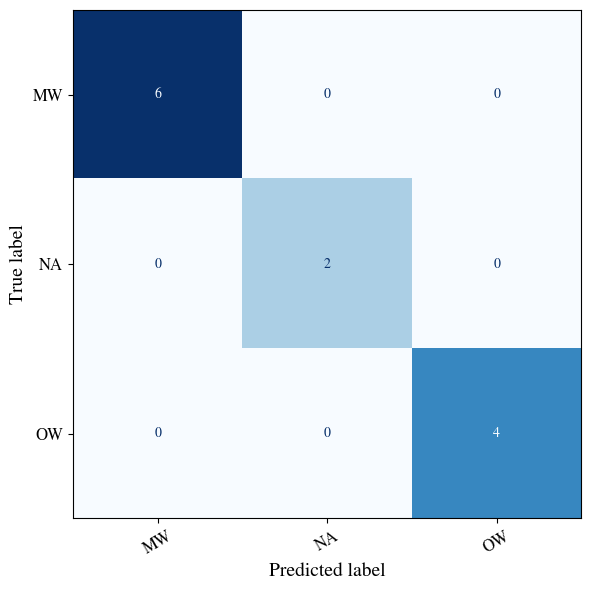

In [ ]:
best_material_model = clone(material_models[best_material_name])
best_material_model.fit(X_train_mat, y_train_mat)

best_material_pred = best_material_model.predict(X_test_mat)

material_labels = list(range(len(material_encoder.classes_)))
material_class_names = [str(x) for x in material_encoder.classes_]

test_material_accuracy = accuracy_score(y_test_mat, best_material_pred)
test_material_bal_accuracy = balanced_accuracy_score(y_test_mat, best_material_pred)
test_material_f1_macro = f1_score(y_test_mat, best_material_pred, average="macro")

print("=== MATERIAL TEST RESULTS ===")
print(f"Accuracy:          {test_material_accuracy:.4f}")
print(f"Balanced accuracy: {test_material_bal_accuracy:.4f}")
print(f"Macro F1:          {test_material_f1_macro:.4f}")

print("\n=== MATERIAL CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test_mat,
        best_material_pred,
        labels=material_labels,
        target_names=material_class_names,
        zero_division=0
    )
)

cm_mat = confusion_matrix(
    y_test_mat,
    best_material_pred,
    labels=material_labels
)

disp_mat = ConfusionMatrixDisplay(
    confusion_matrix=cm_mat,
    display_labels=material_class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
disp_mat.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title(f"")
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
save_pdf(fig, "fig01_confusion_matrix_material")
plt.show()


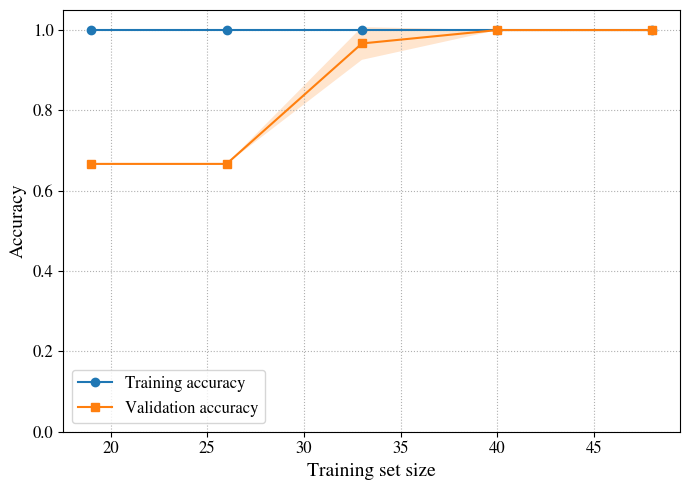

In [ ]:
cv_curve_material = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    clone(material_models[best_material_name]),
    X_material,
    y_material_enc,
    cv=cv_curve_material,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.4, 1.0, 5),
    error_score=np.nan
)

train_mean = np.nanmean(train_scores, axis=1)
train_std = np.nanstd(train_scores, axis=1)
val_mean = np.nanmean(val_scores, axis=1)
val_std = np.nanstd(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
ax.plot(train_sizes, val_mean, marker="s", label="Validation accuracy")

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.set_title(f"")
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle=":")
ax.legend()

fig.tight_layout()
save_pdf(fig, "fig02_learning_curve_material")
plt.show()


In [ ]:
def train_percentage_classifiers(df_sub, material_name):
    X = df_sub[["young_modulus", "stress", "strain"]].copy()
    y = df_sub["percentage"].copy()

    pct_encoder = LabelEncoder()
    y_enc = pct_encoder.fit_transform(y)

    class_counts = pd.Series(y_enc).value_counts().sort_index()
    min_class_count = class_counts.min()

    print(f"\n=== {material_name} - CLASS COUNTS ===")
    for cls_idx, count in class_counts.items():
        original_label = pct_encoder.inverse_transform([cls_idx])[0]
        print(f"Class {original_label}: {count}")

    if min_class_count < 2:
        raise ValueError(
            f"Material {material_name}: at least one percentage class has fewer than 2 samples."
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_enc,
        test_size=0.2,
        random_state=42,
        stratify=y_enc
    )

    # IMPORTANTE:
    # il numero di fold deve essere compatibile con il TRAIN SET, non con il dataset completo.
    train_class_counts = pd.Series(y_train).value_counts()
    min_train_class_count = int(train_class_counts.min())

    if min_train_class_count < 2:
        raise ValueError(
            f"Material {material_name}: after train/test split, at least one class has fewer than 2 train samples."
        )

    n_splits_safe = min(5, min_train_class_count)

    classifiers = {
        "RandomForestClassifier": ImbPipeline([
            ("model", RandomForestClassifier(
                n_estimators=200,
                max_depth=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "LogisticRegression": ImbPipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "SVC": ImbPipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                probability=True,
                class_weight="balanced",
                random_state=42
            ))
        ])
    }

    cv = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    rows = []
    best_name = None
    best_score = -np.inf

    for clf_name, base_model in classifiers.items():
        clf = clone(base_model)

        cv_res = cross_validate(
            clf,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "accuracy": "accuracy",
                "balanced_accuracy": "balanced_accuracy",
                "f1_macro": "f1_macro"
            },
            return_train_score=True,
            n_jobs=-1,
            error_score=np.nan
        )

        row = {
            "classifier": clf_name,
            "cv_train_accuracy_mean": np.nanmean(cv_res["train_accuracy"]),
            "cv_val_accuracy_mean": np.nanmean(cv_res["test_accuracy"]),
            "cv_val_accuracy_std": np.nanstd(cv_res["test_accuracy"]),
            "cv_val_bal_accuracy_mean": np.nanmean(cv_res["test_balanced_accuracy"]),
            "cv_val_f1_macro_mean": np.nanmean(cv_res["test_f1_macro"]),
            "cv_gap_mean": np.nanmean(cv_res["train_accuracy"] - cv_res["test_accuracy"])
        }

        rows.append(row)

        score_for_selection = row["cv_val_f1_macro_mean"]
        if not np.isnan(score_for_selection) and score_for_selection > best_score:
            best_score = score_for_selection
            best_name = clf_name

    results_df = pd.DataFrame(rows).sort_values(
        ["cv_val_f1_macro_mean", "cv_val_bal_accuracy_mean", "cv_val_accuracy_mean"],
        ascending=False
    )

    trained_models = {}
    for clf_name, base_model in classifiers.items():
        clf = clone(base_model)
        clf.fit(X_train, y_train)
        trained_models[clf_name] = clf

    best_model = trained_models[best_name]
    y_test_pred = best_model.predict(X_test)

    percentage_labels = list(range(len(pct_encoder.classes_)))
    percentage_class_names = [str(x) for x in pct_encoder.classes_]

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_bal_accuracy = balanced_accuracy_score(y_test, y_test_pred)
    test_f1_macro = f1_score(y_test, y_test_pred, average="macro")

    print(f"\n=== PERCENTAGE CLASSIFICATION - {material_name} ===")
    print("Best classifier:", best_name)
    print(f"CV folds used:           {n_splits_safe}")
    print(f"Test accuracy:           {test_accuracy:.4f}")
    print(f"Test balanced accuracy:  {test_bal_accuracy:.4f}")
    print(f"Test macro F1:           {test_f1_macro:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_test_pred,
            labels=percentage_labels,
            target_names=percentage_class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=percentage_labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=percentage_class_names
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    ax.set_title(f"")
    ax.tick_params(axis="x", rotation=30)

    fig.tight_layout()
    save_pdf(fig, f"fig03_confusion_matrix_percentage_{material_name.lower()}")
    plt.show()

    return {
        "material_name": material_name,
        "X": X,
        "y": y,
        "encoder": pct_encoder,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "classifiers": classifiers,
        "trained_models": trained_models,
        "best_name": best_name,
        "best_model": best_model,
        "best_test_pred": y_test_pred,
        "results_df": results_df,
        "test_accuracy": test_accuracy,
        "test_bal_accuracy": test_bal_accuracy,
        "test_f1_macro": test_f1_macro,
        "n_splits_used": n_splits_safe
    }


In [ ]:
df_MW = df[df["material"] == "MW"].copy()
df_OW = df[df["material"] == "OW"].copy()
df_NA = df[df["material"] == "NA"].copy()

print("MW shape:", df_MW.shape)
print("OW shape:", df_OW.shape)
print("NA shape:", df_NA.shape)

print("\nMW percentage classes:", sorted(df_MW["percentage"].unique()))
print("OW percentage classes:", sorted(df_OW["percentage"].unique()))
print("NA percentage classes:", sorted(df_NA["percentage"].unique()))

MW shape: (30, 6)
OW shape: (20, 6)
NA shape: (10, 6)

MW percentage classes: [np.int64(10), np.int64(20), np.int64(30)]
OW percentage classes: [np.int64(10), np.int64(20)]
NA percentage classes: [np.int64(0)]



=== MW - CLASS COUNTS ===
Class 10: 10
Class 20: 10
Class 30: 10

=== PERCENTAGE CLASSIFICATION - MW ===
Best classifier: RandomForestClassifier
CV folds used:           5
Test accuracy:           1.0000
Test balanced accuracy:  1.0000
Test macro F1:           1.0000

Classification report:
              precision    recall  f1-score   support

          10       1.00      1.00      1.00         2
          20       1.00      1.00      1.00         2
          30       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



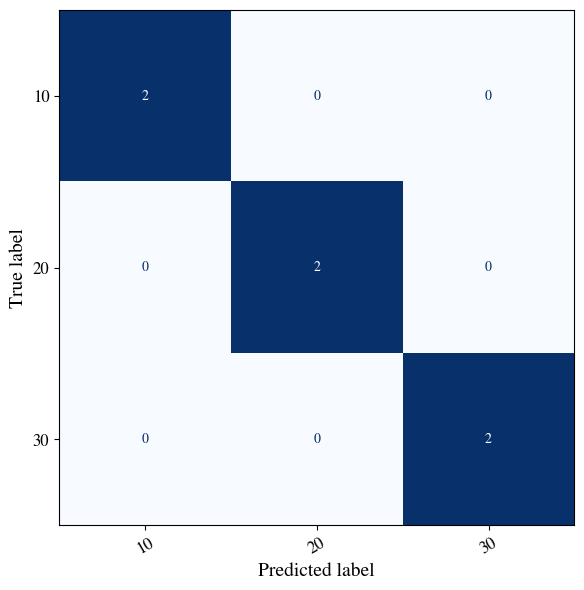


=== OW - CLASS COUNTS ===
Class 10: 10
Class 20: 10

=== PERCENTAGE CLASSIFICATION - OW ===
Best classifier: RandomForestClassifier
CV folds used:           5
Test accuracy:           1.0000
Test balanced accuracy:  1.0000
Test macro F1:           1.0000

Classification report:
              precision    recall  f1-score   support

          10       1.00      1.00      1.00         2
          20       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



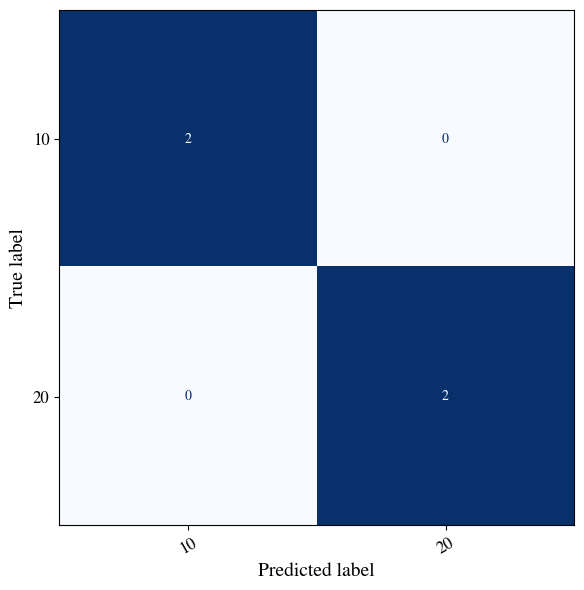

In [ ]:
mw_percentage_system = train_percentage_classifiers(df_MW, "MW")
ow_percentage_system = train_percentage_classifiers(df_OW, "OW")

In [ ]:
print("=== MW PERCENTAGE CLASSIFICATION RESULTS ===")
display(mw_percentage_system["results_df"])

print("\n=== OW PERCENTAGE CLASSIFICATION RESULTS ===")
display(ow_percentage_system["results_df"])

=== MW PERCENTAGE CLASSIFICATION RESULTS ===


,classifier,cv_train_accuracy_mean,cv_val_accuracy_mean,cv_val_accuracy_std,cv_val_bal_accuracy_mean,cv_val_f1_macro_mean,cv_gap_mean
0,RandomForestClassifier,1.0,1.0,0.0,1.0,1.0,0.0
1,LogisticRegression,1.0,1.0,0.0,1.0,1.0,0.0
2,SVC,1.0,1.0,0.0,1.0,1.0,0.0



=== OW PERCENTAGE CLASSIFICATION RESULTS ===


,classifier,cv_train_accuracy_mean,cv_val_accuracy_mean,cv_val_accuracy_std,cv_val_bal_accuracy_mean,cv_val_f1_macro_mean,cv_gap_mean
0,RandomForestClassifier,1.0,1.0,0.0,1.0,1.0,0.0
1,LogisticRegression,1.0,1.0,0.0,1.0,1.0,0.0
2,SVC,1.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

def check_classification_overfitting(system_name, pct_system):

    X_train = pct_system["X_train"]
    y_train = pct_system["y_train"]

    best_name = pct_system["best_name"]
    best_model = clone(pct_system["trained_models"][best_name])

    min_train_class_count = int(pd.Series(y_train).value_counts().min())
    n_splits_safe = min(5, min_train_class_count)

    if n_splits_safe < 2:
        raise ValueError(
            f"{system_name}: at least one class has fewer than 2 train samples."
        )

    cv = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
            "balanced_accuracy": "balanced_accuracy"
        },
        return_train_score=True,
        n_jobs=-1
    )

    # ===== MEDIE =====
    train_acc_mean = np.mean(scores["train_accuracy"])
    val_acc_mean = np.mean(scores["test_accuracy"])

    train_f1_mean = np.mean(scores["train_f1_macro"])
    val_f1_mean = np.mean(scores["test_f1_macro"])

    # ===== GAP (coerente con regressione) =====
    acc_gap_abs = train_acc_mean - val_acc_mean
    acc_gap_rel = acc_gap_abs / train_acc_mean if train_acc_mean > 0 else np.nan

    f1_gap_abs = np.mean(scores["train_f1_macro"] - scores["test_f1_macro"])
    f1_gap_rel = f1_gap_abs / val_f1_mean if val_f1_mean > 0 else np.nan

    # ===== STABILITÀ =====
    val_f1_std = np.std(scores["test_f1_macro"])
    stability = val_f1_std / val_f1_mean if val_f1_mean > 0 else np.nan

    # ===== RISCHIO (coerente con regressione) =====
    if f1_gap_rel < 0.10:
        risk = "low"
    elif f1_gap_rel < 0.25:
        risk = "moderate"
    else:
        risk = "high"

    return {
        "system": system_name,
        "best_classifier": best_name,
        "cv_folds_used": n_splits_safe,

        "train_acc_mean": train_acc_mean,
        "val_acc_mean": val_acc_mean,

        "train_f1_mean": train_f1_mean,
        "val_f1_mean": val_f1_mean,

        "acc_gap_abs": acc_gap_abs,
        "acc_gap_rel": acc_gap_rel,

        "f1_gap_abs": f1_gap_abs,
        "f1_gap_rel": f1_gap_rel,

        "val_f1_std": val_f1_std,
        "stability": stability,

        "overfitting_risk": risk
    }


In [ ]:
def print_overfitting_report(report):
    print(f"System: {report['system']}")
    print(f"Best model: {report['best_classifier']}")
    print(f"Train ACC: {report['train_acc_mean']:.3f}")
    print(f"Val ACC:   {report['val_acc_mean']:.3f}")
    print(f"Train F1:  {report['train_f1_mean']:.3f}")
    print(f"Val F1:    {report['val_f1_mean']:.3f}")
    print(f"ACC gap:   {report['acc_gap_abs']:.3f} ({report['acc_gap_rel']*100:.1f}%)")
    print(f"F1 gap:    {report['f1_gap_abs']:.3f} ({report['f1_gap_rel']*100:.1f}%)")
    print(f"Stability: {report['stability']:.3f}")
    print(f"Risk:      {report['overfitting_risk']}")
    print("-" * 40)


# Check overfitting for percentage classification models
mw_overfit_df = check_classification_overfitting("MW", mw_percentage_system)
ow_overfit_df = check_classification_overfitting("OW", ow_percentage_system)


print("=== OVERFITTING CHECK - MW PERCENTAGE ===")
print_overfitting_report(mw_overfit_df)

print("=== OVERFITTING CHECK - OW PERCENTAGE ===")
print_overfitting_report(ow_overfit_df)

=== OVERFITTING CHECK - MW PERCENTAGE ===
System: MW
Best model: RandomForestClassifier
Train ACC: 1.000
Val ACC:   1.000
Train F1:  1.000
Val F1:    1.000
ACC gap:   0.000 (0.0%)
F1 gap:    0.000 (0.0%)
Stability: 0.000
Risk:      low
----------------------------------------
=== OVERFITTING CHECK - OW PERCENTAGE ===
System: OW
Best model: RandomForestClassifier
Train ACC: 1.000
Val ACC:   1.000
Train F1:  1.000
Val F1:    1.000
ACC gap:   0.000 (0.0%)
F1 gap:    0.000 (0.0%)
Stability: 0.000
Risk:      low
----------------------------------------


In [ ]:
def run_percentage_cv(df_sub, pct_system, title):
    X = df_sub[["young_modulus", "stress", "strain"]].copy()
    y = df_sub["percentage"].copy()

    encoder = LabelEncoder()
    y_enc = encoder.fit_transform(y)

    n_splits_safe = pct_system["n_splits_used"]

    cv = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    best_name = pct_system["best_name"]
    best_pipeline = clone(pct_system["classifiers"][best_name])

    cv_results = cross_validate(
        best_pipeline,
        X,
        y_enc,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro"
        },
        return_train_score=True,
        n_jobs=-1,
        error_score=np.nan
    )

    cv_summary = pd.DataFrame({
        "fold": range(1, n_splits_safe + 1),
        "train_accuracy": cv_results["train_accuracy"],
        "val_accuracy": cv_results["test_accuracy"],
        "val_bal_accuracy": cv_results["test_balanced_accuracy"],
        "val_f1_macro": cv_results["test_f1_macro"]
    })

    print(f"=== CROSS-VALIDATION - {title} ===")
    display(cv_summary)
    print("Mean train accuracy:", np.nanmean(cv_summary["train_accuracy"]))
    print("Mean val accuracy:  ", np.nanmean(cv_summary["val_accuracy"]))
    print("Mean val bal acc:   ", np.nanmean(cv_summary["val_bal_accuracy"]))
    print("Mean val macro F1:  ", np.nanmean(cv_summary["val_f1_macro"]))
    print("Mean gap:           ", np.nanmean(cv_summary["train_accuracy"] - cv_summary["val_accuracy"]))

In [ ]:
run_percentage_cv(df_MW, mw_percentage_system, "MW")
run_percentage_cv(df_OW, ow_percentage_system, "OW")

=== CROSS-VALIDATION - MW ===


,fold,train_accuracy,val_accuracy,val_bal_accuracy,val_f1_macro
0,1,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0


Mean train accuracy: 1.0
Mean val accuracy:   1.0
Mean val bal acc:    1.0
Mean val macro F1:   1.0
Mean gap:            0.0
=== CROSS-VALIDATION - OW ===


,fold,train_accuracy,val_accuracy,val_bal_accuracy,val_f1_macro
0,1,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0


Mean train accuracy: 1.0
Mean val accuracy:   1.0
Mean val bal acc:    1.0
Mean val macro F1:   1.0
Mean gap:            0.0


In [ ]:
def plot_percentage_learning_curve(df_sub, pct_system, title, filename):
    X = df_sub[["young_modulus", "stress", "strain"]].copy()
    y = df_sub["percentage"].copy()

    encoder = LabelEncoder()
    y_enc = encoder.fit_transform(y)

    best_name = pct_system["best_name"]
    best_pipeline = clone(pct_system["classifiers"][best_name])

    n_splits_safe = pct_system["n_splits_used"]

    cv_curve = StratifiedKFold(
        n_splits=n_splits_safe,
        shuffle=True,
        random_state=42
    )

    train_sizes, train_scores, val_scores = learning_curve(
        best_pipeline,
        X,
        y_enc,
        cv=cv_curve,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.4, 1.0, 5),
        error_score=np.nan
    )

    train_mean = np.nanmean(train_scores, axis=1)
    train_std = np.nanstd(train_scores, axis=1)
    val_mean = np.nanmean(val_scores, axis=1)
    val_std = np.nanstd(val_scores, axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
    ax.plot(train_sizes, val_mean, marker="s", label="Validation accuracy")

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2
    )

    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"")
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":")
    ax.legend()

    fig.tight_layout()
    save_pdf(fig, filename)
    plt.show()


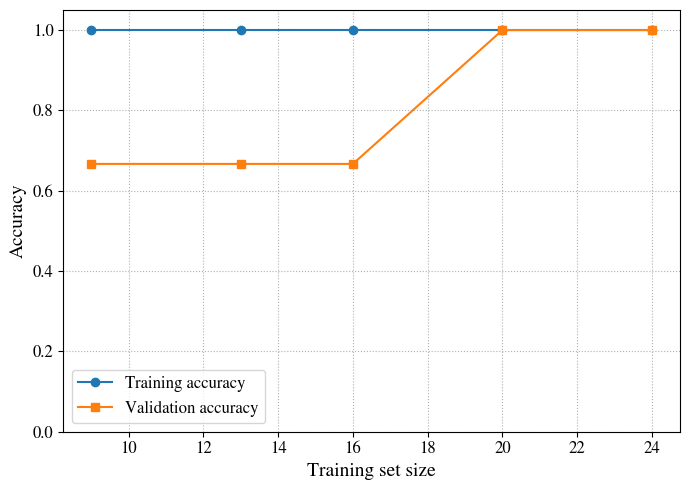

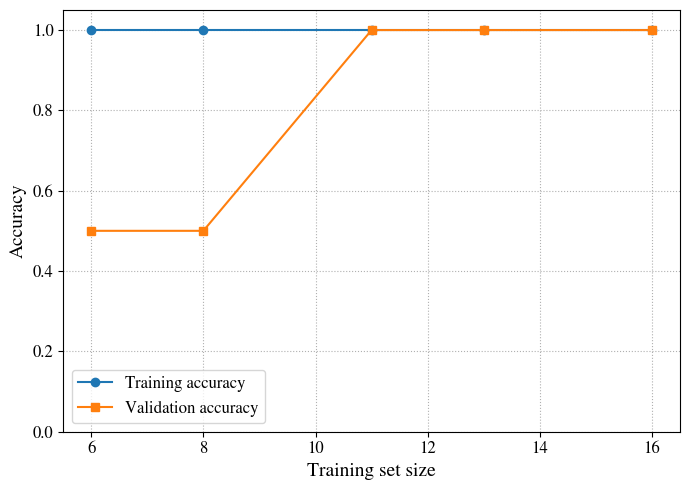

In [ ]:
plot_percentage_learning_curve(
    df_MW,
    mw_percentage_system,
    "MW",
    "fig04_learning_curve_percentage_mw"
)

plot_percentage_learning_curve(
    df_OW,
    ow_percentage_system,
    "OW",
    "fig05_learning_curve_percentage_ow"
)


In [ ]:
def predict_material_and_percentage_classification(young, stress, strain):
    X_input = pd.DataFrame(
        [[young, stress, strain]],
        columns=["young_modulus", "stress", "strain"]
    )

    print("\n=== INPUT RECEIVED ===")
    print(X_input)

    pred_material_enc = best_material_model.predict(X_input)[0]
    pred_material = material_encoder.inverse_transform([pred_material_enc])[0]

    print("\n=== MATERIAL CLASSIFICATION RESULT ===")
    print(f"Best material classifier: {best_material_name}")
    print(f"Predicted material: {pred_material}")

    if hasattr(best_material_model, "predict_proba"):
        probs = best_material_model.predict_proba(X_input)[0]
        print("Material class probabilities:")
        for i, p in enumerate(probs):
            mat = material_encoder.inverse_transform([i])[0]
            print(f"  {mat}: {p:.3f}")

    if pred_material == "NA":
        print("\n=== PERCENTAGE RESULT ===")
        print("Material NA detected -> no additive -> percentage = 0%")

        return pd.DataFrame([{
            "predicted_material": "NA",
            "classifier": "Constant",
            "predicted_percentage": 0.0
        }])

    if pred_material == "MW":
        pct_system = mw_percentage_system
    elif pred_material == "OW":
        pct_system = ow_percentage_system
    else:
        raise ValueError(f"Unsupported predicted material: {pred_material}")

    best_pct_name = pct_system["best_name"]
    best_pct_model = pct_system["best_model"]
    pct_encoder = pct_system["encoder"]

    pred_pct_enc = best_pct_model.predict(X_input)[0]
    pred_pct = pct_encoder.inverse_transform([pred_pct_enc])[0]

    print("\n=== PERCENTAGE CLASSIFICATION RESULT ===")
    print(f"Best percentage classifier for {pred_material}: {best_pct_name}")
    print(f"Predicted percentage: {pred_pct}")

    if hasattr(best_pct_model, "predict_proba"):
        pct_probs = best_pct_model.predict_proba(X_input)[0]
        print("Percentage class probabilities:")
        for i, p in enumerate(pct_probs):
            pct_class = pct_encoder.inverse_transform([i])[0]
            print(f"  {pct_class}: {p:.3f}")

    return pd.DataFrame([{
        "predicted_material": pred_material,
        "material_classifier": best_material_name,
        "predicted_percentage": pred_pct,
        "percentage_classifier": best_pct_name
    }])

In [ ]:
results_input = predict_material_and_percentage_classification(
    young=3.89,
    stress=47.46,
    strain=1.80
)

results_input


=== INPUT RECEIVED ===
   young_modulus  stress  strain
0           3.89   47.46     1.8

=== MATERIAL CLASSIFICATION RESULT ===
Best material classifier: SVC
Predicted material: MW
Material class probabilities:
  MW: 0.930
  NA: 0.024
  OW: 0.046

=== PERCENTAGE CLASSIFICATION RESULT ===
Best percentage classifier for MW: RandomForestClassifier
Predicted percentage: 30
Percentage class probabilities:
  10: 0.000
  20: 0.200
  30: 0.800


,predicted_material,material_classifier,predicted_percentage,percentage_classifier
0,MW,SVC,30,RandomForestClassifier


In [ ]:
results_input = predict_material_and_percentage_classification(
    young=3.7,
    stress=100,
    strain=4.80
)

results_input


=== INPUT RECEIVED ===
   young_modulus  stress  strain
0            3.7     100     4.8

=== MATERIAL CLASSIFICATION RESULT ===
Best material classifier: SVC
Predicted material: NA
Material class probabilities:
  MW: 0.115
  NA: 0.819
  OW: 0.066

=== PERCENTAGE RESULT ===
Material NA detected -> no additive -> percentage = 0%


,predicted_material,classifier,predicted_percentage
0,NA,Constant,0.0


In [ ]:
results_input = predict_material_and_percentage_classification(
    young=2.1,
    stress=40.46,
    strain=3
)

results_input


=== INPUT RECEIVED ===
   young_modulus  stress  strain
0            2.1   40.46       3

=== MATERIAL CLASSIFICATION RESULT ===
Best material classifier: SVC
Predicted material: OW
Material class probabilities:
  MW: 0.054
  NA: 0.028
  OW: 0.918

=== PERCENTAGE CLASSIFICATION RESULT ===
Best percentage classifier for OW: RandomForestClassifier
Predicted percentage: 10
Percentage class probabilities:
  10: 0.974
  20: 0.026


,predicted_material,material_classifier,predicted_percentage,percentage_classifier
0,OW,SVC,10,RandomForestClassifier


In [ ]:
# Optional: create a zip archive of the generated PDF figures.
# This cell is safe for local/Jupyter execution and does not require Google Colab.

import shutil
from pathlib import Path

figures_dir = Path("figures_pdf")
if figures_dir.exists():
    shutil.make_archive("figures_pdf", "zip", figures_dir)
    print("Created figures_pdf.zip")
else:
    print("No figures_pdf folder found.")
